https://www.cs.toronto.edu/~kriz/cifar.html cifar10

# Cifar10 Hypertuning

## Imports

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

import mlflow
import mlflow.pytorch
from pathlib import Path
from functools import partial

from mltrainer import TrainerSettings, ReportTypes, Trainer
from mltrainer.metrics import Accuracy

from datetime import datetime

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
from torch.utils.data import Subset

train_subset = Subset(train_dataset, list(range(10000)))
test_subset = Subset(test_dataset, list(range(2000)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64)

Files already downloaded and verified


c:\Users\Alex\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


## Doublechecking

In [3]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

# torch.Size([64, 3, 32, 32]) batch -64, channel = 3, height = 3, width =3
# torch.Size([64])

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [4]:
print(len(train_dataset))
print(len(test_dataset))

50000
10000


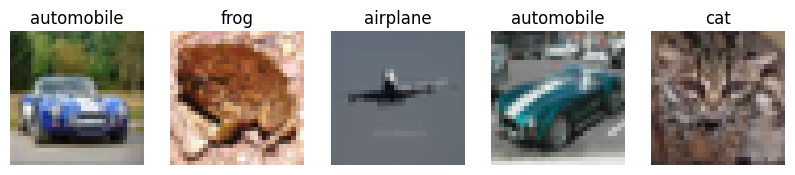

In [5]:
classes = train_dataset.classes

fig, axes = plt.subplots(1, 5, figsize=(10,3))

for i in range(5):
    img = images[i] / 2 + 0.5
    img = img.permute(1,2,0)

    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis("off")

plt.show()

# Model

## Making the model

In [6]:
class CNN(nn.Module):
    def __init__(self, num_layers=2, num_filters=32):
        super().__init__()
        
        layers = []
        in_channels = 3
        
        for _ in range(num_layers):
            layers.append(nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2))
            in_channels = num_filters
        
        self.conv = nn.Sequential(*layers)
        
        conv_out_size = num_filters * (32 // (2 ** num_layers))**2
        self.fc = nn.Linear(conv_out_size, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x.view(x.size(0), -1))
        return x

In [7]:
def train_model(model, train_loader, test_loader, epochs=5, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")
    
    return model

## Small Experiment

In [8]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("CNN")

modeldir = Path("cnn_models").resolve()
modeldir.mkdir(parents=True, exist_ok=True)

2026/03/14 17:50:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/14 17:50:07 INFO mlflow.store.db.utils: Updating database tables
2026-03-14 17:50:07 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-03-14 17:50:07 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026-03-14 17:50:08 INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
2026-03-14 17:50:08 INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026-03-14 17:50:08 INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2026-03-14 17:50:08 INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2026-03-14 17:50:08 INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2026-03-14 17:50:08 INFO  [alembic.runtime.mig

In [9]:
from pathlib import Path

modeldir = Path("cnn_models").resolve()
modeldir.mkdir(parents=True, exist_ok=True)

In [10]:
mlflow.set_experiment("cnn_layers_filters")
model_configs = [
    {"name": "Exp1", "num_layers": 1, "num_filters": 32, "lr": 0.001},
    {"name": "Exp2", "num_layers": 2, "num_filters": 128, "lr": 0.001},
    {"name": "Exp3", "num_layers": 3, "num_filters": 64, "lr": 0.001},
    {"name": "Exp4", "num_layers": 2, "num_filters": 16, "lr": 0.001}
]

2026/03/14 17:50:09 INFO mlflow.tracking.fluent: Experiment with name 'cnn_layers_filters' does not exist. Creating a new experiment.


In [11]:
accuracy = Accuracy()

settings = TrainerSettings(
    epochs=3, 
    metrics=[accuracy],
    logdir=Path("gestures"),
    train_steps=len(train_subset),
    valid_steps=len(test_subset),
    reporttypes=[ReportTypes.TOML, ReportTypes.TENSORBOARD, ReportTypes.MLFLOW],
    scheduler_kwargs={"factor": 0.5, "patience": 5},
    earlystop_kwargs = {
        "save": False,
        "verbose": True,
        "patience": 5,
        "delta": 0.0,
    }
)
settings

device = "cuda" if torch.cuda.is_available() else "cpu"

2026-03-14 17:50:09.170 | INFO     | mltrainer.settings:check_path:60 - Created logdir c:\Users\Alex\Documents\GitHub\portfolio-example\4-hypertuning-ray\gestures


In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()

for trial, cfg in enumerate(model_configs):
    with mlflow.start_run():
        mlflow.set_tag("model", "cnn-cifar10")
        mlflow.set_tag("trial", trial)
        mlflow.set_tag("name", cfg["name"])
        mlflow.log_params(cfg)

        model = CNN(num_layers=cfg["num_layers"], num_filters=cfg["num_filters"]).to(device)

        trainer = Trainer(
            model=model,
            settings=settings,
            loss_fn=loss_fn,
            optimizer=optim.Adam,
            traindataloader=train_loader,
            validdataloader=test_loader,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device,
        )
        trainer.loop()

        if not settings.earlystop_kwargs["save"]:
            from datetime import datetime
            tag = datetime.now().strftime("%Y%m%d-%H%M-")
            modelpath = modeldir / (tag + "model.pt")
            torch.save(model, modelpath)
            mlflow.log_artifact(modelpath)

## Full Training

In [17]:
conv_layers_options = [1, 2, 3, 4]
conv_filters_options = [16, 32, 64, 128]
learning_rate = 0.001

loss_fn = torch.nn.CrossEntropyLoss()

combinations = []
for l in conv_layers_options:
    for f in conv_filters_options:
        combinations.append({"num_layers": l, "num_filters": f})

for trial, cfg in enumerate(combinations):
    num_layers = cfg["num_layers"]
    num_filters = cfg["num_filters"]

    with mlflow.start_run():
        cfg_name = f"layers{num_layers}_filters{num_filters}"
        mlflow.set_tag("model", "cnn-cifar10")
        mlflow.set_tag("trial", trial)
        mlflow.set_tag("name", cfg_name)

        mlflow.log_params({
            "num_layers": num_layers,
            "num_filters": num_filters,
            "learning_rate": learning_rate
        })

        model = CNN(num_layers=num_layers, num_filters=num_filters).to(device)

        trainer = Trainer(
            model=model,
            settings=settings,
            loss_fn=loss_fn,
            optimizer=optim.Adam,
            traindataloader=train_loader,
            validdataloader=test_loader,
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device,
        )

        trainer.loop()

        tag = datetime.now().strftime("%Y%m%d-%H%M-")
        modelpath = modeldir / f"{tag}{cfg_name}_trial{trial}.pt"
        torch.save(model, modelpath)
        mlflow.log_artifact(modelpath)

        print(f"Run complete for trial {trial}: {cfg_name}")

2026-03-14 18:28:28.434 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to gestures\20260314-182828
2026-03-14 18:28:28.435 | INFO     | mltrainer.trainer:__init__:66 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|██████████| 10000/10000 [02:32<00:00, 65.38it/s]
2026-03-14 18:31:30.228 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.5096 test 2.0849 metric ['0.6094']
100%|██████████| 10000/10000 [02:33<00:00, 65.10it/s]
2026-03-14 18:34:33.129 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0598 test 3.1917 metric ['0.6094']
2026-03-14 18:34:33.130 | INFO     | mltrainer.trainer:__call__:258 - best loss: 2.0849, current loss 3.1917.Counter 1/5.
100%|██████████| 10000/10000 [02:33<00:00, 65.18it/s]
2026-03-14 18:37:35.759 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0222 test 3.9007 metric ['0.6094']
2026-03-14 18:37:35.759 | INFO     | mltrainer.trainer:__call__:258 - best loss: 2.0849, current 

Run complete for trial 0: layers1_filters16


100%|██████████| 10000/10000 [02:37<00:00, 63.36it/s]
2026-03-14 18:40:42.335 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.3300 test 2.4764 metric ['0.5781']
100%|██████████| 10000/10000 [02:38<00:00, 63.19it/s]
2026-03-14 18:43:48.581 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0260 test 3.5030 metric ['0.5938']
2026-03-14 18:43:48.581 | INFO     | mltrainer.trainer:__call__:258 - best loss: 2.4764, current loss 3.5030.Counter 1/5.
100%|██████████| 10000/10000 [02:38<00:00, 63.16it/s]
2026-03-14 18:46:54.789 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0106 test 3.4885 metric ['0.5625']
2026-03-14 18:46:54.790 | INFO     | mltrainer.trainer:__call__:258 - best loss: 2.4764, current loss 3.4885.Counter 2/5.
100%|██████████| 3/3 [09:18<00:00, 186.31s/it]
2026-03-14 18:46:54.871 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to gestures\20260314-184654
2026-03-14 18:46:54.872 | INFO     | mltrainer.trainer:__init__:66 - Found e

Run complete for trial 1: layers1_filters32


100%|██████████| 10000/10000 [02:49<00:00, 59.09it/s]
2026-03-14 18:50:14.115 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.2285 test 3.9494 metric ['0.5781']
100%|██████████| 10000/10000 [02:50<00:00, 58.69it/s]
2026-03-14 18:53:35.429 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0192 test 3.1110 metric ['0.6406']
100%|██████████| 10000/10000 [02:49<00:00, 58.84it/s]
2026-03-14 18:56:55.789 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0185 test 3.1168 metric ['0.5938']
2026-03-14 18:56:55.790 | INFO     | mltrainer.trainer:__call__:258 - best loss: 3.1110, current loss 3.1168.Counter 1/5.
100%|██████████| 3/3 [10:00<00:00, 200.30s/it]
2026-03-14 18:56:55.870 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to gestures\20260314-185655
2026-03-14 18:56:55.871 | INFO     | mltrainer.trainer:__init__:66 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.


...

Run complete for trial 13: layers4_filters32


100%|██████████| 10000/10000 [03:07<00:00, 53.29it/s]
2026-03-14 20:54:20.782 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.2744 test 3.8986 metric ['0.5156']
100%|██████████| 10000/10000 [03:07<00:00, 53.30it/s]
2026-03-14 20:57:59.543 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0408 test 4.9560 metric ['0.6562']
2026-03-14 20:57:59.544 | INFO     | mltrainer.trainer:__call__:258 - best loss: 3.8986, current loss 4.9560.Counter 1/5.
100%|██████████| 10000/10000 [03:07<00:00, 53.21it/s]
2026-03-14 21:01:38.585 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0326 test 7.3329 metric ['0.6094']
2026-03-14 21:01:38.586 | INFO     | mltrainer.trainer:__call__:258 - best loss: 3.8986, current loss 7.3329.Counter 2/5.
100%|██████████| 3/3 [10:56<00:00, 218.84s/it]
2026-03-14 21:01:38.669 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to gestures\20260314-210138
2026-03-14 21:01:38.670 | INFO     | mltrainer.trainer:__init__:66 - Found e

Run complete for trial 14: layers4_filters64


100%|██████████| 10000/10000 [03:19<00:00, 50.00it/s]
2026-03-14 21:05:31.164 | INFO     | mltrainer.trainer:report:215 - Epoch 0 train 0.1805 test 3.5029 metric ['0.6250']
100%|██████████| 10000/10000 [03:22<00:00, 49.48it/s]
2026-03-14 21:09:25.656 | INFO     | mltrainer.trainer:report:215 - Epoch 1 train 0.0325 test 4.4560 metric ['0.6719']
2026-03-14 21:09:25.656 | INFO     | mltrainer.trainer:__call__:258 - best loss: 3.5029, current loss 4.4560.Counter 1/5.
100%|██████████| 10000/10000 [03:19<00:00, 50.07it/s]
2026-03-14 21:13:17.993 | INFO     | mltrainer.trainer:report:215 - Epoch 2 train 0.0278 test 5.5814 metric ['0.6562']
2026-03-14 21:13:17.994 | INFO     | mltrainer.trainer:__call__:258 - best loss: 3.5029, current loss 5.5814.Counter 2/5.
100%|██████████| 3/3 [11:39<00:00, 233.11s/it]

Run complete for trial 15: layers4_filters128
